# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [184]:
import polars as pl
import numpy as np
import networkx as nx  
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.graph_fct as graph_fct


# 1. subgraph construction and comparison

In [32]:
# original graph
df_relations = pl.read_parquet(f"{config.BasicConfig().relation_path}")
df_mapped = pl.read_parquet(f"{config.BasicConfig().mapped_path}")
mapped_ids = df_mapped["id"].unique().to_list()
G_original = graph_fct.build_relations_graph(df_relations, col_src="src.id", col_dst="dst.id", col_relation="relation")
print(f"Original graph: {G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges, number of connected components: {nx.number_weakly_connected_components(G_original)},number of distinct relation types: {len(set(nx.get_edge_attributes(G_original, 'relation').values()))}")

Original graph: 447420 nodes, 1684197 edges, number of connected components: 1,number of distinct relation types: 113


In [33]:
# computed subgraph 
id_to_label, G_d = graph_fct.get_combined_combined_subgraphs_and_id2label()
print(f"Computed subgraph: {G_d.number_of_nodes()} nodes, {G_d.number_of_edges()} edges, number of connected components: {nx.number_weakly_connected_components(G_d)},number of distinct relation types: {len(set(nx.get_edge_attributes(G_d, 'relation').values()))}")

Computed subgraph: 75964 nodes, 293146 edges, number of connected components: 2,number of distinct relation types: 103


In [38]:
# omited relation types in the computed subgraph
omited_relation_types = set(nx.get_edge_attributes(G_original, 'relation').values()) - set(nx.get_edge_attributes(G_d, 'relation').values())
omited_relation_types

{'HAS_ABSORBABILITY',
 'HAS_COATING_MATERIAL',
 'HAS_FILLING',
 'HAS_INGREDIENT_QUALITATIVE_STRENGTH',
 'HAS_SURFACE_TEXTURE',
 'MEASUREMENT_METHOD',
 'PROCESS_EXTENDS_TO',
 'REGIONAL_PART_OF',
 'RELATIVE_TO_PART_OF',
 'TOWARDS'}

# rank best methods

In [ ]:
BASELINE_FAMILY = {'closeness_centrality': 'centrality-based',
 'discrete_set_cover': 'ours(ablation)',
 'highest_degree': 'degree-based',
 'highest_degree_dist_1': 'degree-based',
 'k_random_all_samples': 'random',
 'most_children': 'degree-based',
 'pagerank': 'centrality-based',
 'personalized_pagerank': 'centrality-based',
 '0.0': 'ours',
 '0.1': 'ours',
 '0.2': 'ours',
 '0.3': 'ours',
 '0.4': 'ours',
 '0.5': 'ours',
 '0.6': 'ours',
 '0.7': 'ours',
 '0.8': 'ours',
 '0.9': 'ours',
 '1.0': 'ours'
 }

compression_level_dict = {
    "high": [500, 6500],      # small k, most compression
    "mid":  [7000, 13000],
    "low":  [13500, 19500],   # large k, least compression
}

METRIC_CORE = ['conciseness', 'distance_score', 'unique_rate', 'unknown_rate', 'semantic_coverage']

higher_is_better = {
    "semantic_coverage": True,
    "distance_score": True,
    "unique_rate": True,
    "conciseness": False,
    "unknown_rate": False,
}

perf_df_all = (pl.read_parquet(config.Results().perf_all)
               .rename({"unk_branche_rate": "uncovered_branche_rate",
                        "uncovered_rate": "unknown_rate"})
               .with_columns(pl.col("file_type").replace(BASELINE_FAMILY).alias("family"))
               .drop("exact_rate"))

# compression rate for each compression level
for compression_level, (k_min, k_max) in compression_level_dict.items():
    print(f"Compression level: {compression_level}, k_min: {k_min}, k_max: {k_max}")
    print(f"compression rate: {k_min/len(mapped_ids):.2%} - {k_max/len(mapped_ids):.2%}")

# rank all methods by each metric, and compute the average rank across all metrics


Compression level: high, k_min: 500, k_max: 6500
compression rate: 1.08% - 14.08%
Compression level: mid, k_min: 7000, k_max: 13000
compression rate: 15.17% - 28.17%
Compression level: low, k_min: 13500, k_max: 19500
compression rate: 29.25% - 42.25%


In [86]:
(perf_df_all.select(["category", "file_type", "k", "family"] + METRIC_CORE)
.with_columns(
        pl.when(pl.col("k").is_between(*compression_level_dict["high"]))
          .then(pl.lit("high"))
        .when(pl.col("k").is_between(*compression_level_dict["mid"]))
          .then(pl.lit("mid"))
        .when(pl.col("k").is_between(*compression_level_dict["low"]))
          .then(pl.lit("low"))
        .otherwise(None)
        .alias("compression_level"))

.with_columns([
        pl.col(m)
          .rank(method="average", descending=higher_is_better[m])
          .over(["family", "compression_level"])
          .alias(f"{m}_rank")
        for m in METRIC_CORE
    ])
.with_columns(pl.mean_horizontal([f"{m}_rank" for m in METRIC_CORE]).alias("avg_rank"))
 .group_by(["compression_level", "family", "file_type"])
 .agg(pl.col("avg_rank").mean().alias("avg_rank_over_k"))
 .sort(["compression_level", "avg_rank_over_k"],)

)

compression_level,family,file_type,avg_rank_over_k
str,str,str,f64
"""high""","""random""","""k_random_all_samples""",7.0
"""high""","""ours(ablation)""","""discrete_set_cover""",7.0
"""high""","""degree-based""","""highest_degree""",17.969231
"""high""","""centrality-based""","""pagerank""",18.469231
"""high""","""centrality-based""","""personalized_pagerank""",18.976923
…,…,…,…
"""mid""","""ours""","""0.3""",81.869231
"""mid""","""ours""","""1.0""",88.992308
"""mid""","""ours""","""0.2""",93.530769


In [134]:
df_rank_input = (
    perf_df_all
    # 2) random: average the 20 draws -> one row per (method, k)
    .group_by(["family", "file_type", "k"])
    .agg([pl.col(m).mean() for m in METRIC_CORE])
    .with_columns(
        pl.when(pl.col("k").is_between(*compression_level_dict["high"])).then(pl.lit("high"))
          .when(pl.col("k").is_between(*compression_level_dict["mid"])).then(pl.lit("mid"))
          .when(pl.col("k").is_between(*compression_level_dict["low"])).then(pl.lit("low"))
          .alias("compression_level"))
)

ranked = (
    df_rank_input
    # 3) rank METHODS against each other at the same k (rank 1 = best)
    .with_columns([
        pl.col(m).rank(method="average", descending=higher_is_better[m])
          .over("k").alias(f"{m}_rank")
        for m in METRIC_CORE])
    .with_columns(pl.mean_horizontal([f"{m}_rank" for m in METRIC_CORE]).alias("avg_rank"))
)

rank_table = (
    ranked
    # 4) average over the 13 k values of each level
    .group_by(["compression_level", "family", "file_type"])
    .agg([pl.col(f"{m}_rank").mean() for m in METRIC_CORE]
         + [pl.col("avg_rank").mean()])
    .sort(["compression_level", "avg_rank"])
)

rank_table.write_csv(config.Results().perf_ranked_csv)

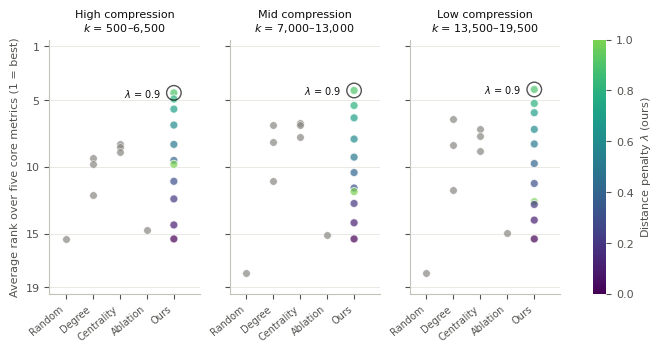

In [163]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

# rank_df = your rank_table (polars); here read from the exported CSV
rank_df = rank_table

LEVELS = [("high", "High compression\n$k$ = 500–6,500"),
          ("mid",  "Mid compression\n$k$ = 7,000–13,000"),
          ("low",  "Low compression\n$k$ = 13,500–19,500")]
FAMILIES = [("random", "Random"), ("degree-based", "Degree"),
            ("centrality-based", "Centrality"), ("ours(ablation)", "Ablation"),
            ("ours", "Ours")]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BASE_COLOR = "#898781"
# sequential blue ramp (steps 250 -> 700) for lambda
# lam_cmap = LinearSegmentedColormap.from_list(
#     "lam", ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"])
# lam_norm = Normalize(0.0, 1.0)
lam_cmap = LinearSegmentedColormap.from_list(
    "lam_viridis", plt.cm.viridis(np.linspace(0.0, 0.8, 256)))
 
plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK2})
fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.3), sharey=True)
x_pos = {fam: i for i, (fam, _) in enumerate(FAMILIES)}
 
for ax, (lvl, title) in zip(axes, LEVELS):
    d = rank_df.filter(pl.col("compression_level") == lvl)
    others = d.filter(pl.col("family") != "ours")
    best_other = others.sort("avg_rank").row(0, named=True)
 
    # baselines: neutral gray, one column per family
    for fam, _ in FAMILIES[:-1]:
        sub = d.filter(pl.col("family") == fam)
        ax.scatter(np.full(sub.height, x_pos[fam]), sub["avg_rank"], s=30, color=BASE_COLOR,
                   edgecolor="white", linewidth=0.5, zorder=3, alpha=0.7)
 
    # ours: one point per lambda, colour = lambda
    ours = d.filter(pl.col("family") == "ours").with_columns(pl.col("file_type").cast(pl.Float64).alias("lam"))
    ax.scatter(np.full(ours.height, x_pos["ours"]), ours["avg_rank"], s=34,
               c=ours["lam"], cmap=lam_cmap, edgecolor="white", linewidth=0.8, zorder=4, alpha=0.7) # norm=lam_norm
    best = ours.sort("avg_rank").row(0, named=True)
    ax.scatter([x_pos["ours"]], [best["avg_rank"]], s=110, facecolor="none",
               edgecolor=INK, linewidth=1.0, zorder=5, alpha=0.7)
    ax.annotate(f"$\\lambda$ = {best['lam']:.1f}", (x_pos["ours"], best["avg_rank"]),
                xytext=(-9, 0), textcoords="offset points", ha="right", va="center",
                fontsize=7, color=INK)
 
    
        
 
    
 
    ax.set_title(title, fontsize=8, color=INK)
    ax.set_xticks(range(len(FAMILIES)))
    ax.set_xticklabels([lab for _, lab in FAMILIES], rotation=40, ha="right", fontsize=7)
    ax.set_xlim(-0.6, len(FAMILIES) - 0.05)
    ax.grid(axis="y", color=GRID, lw=0.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
 
axes[0].set_ylim(19.5, 0.5)                     # rank 1 on top
axes[0].set_yticks([1, 5, 10, 15, 19])
axes[0].set_ylabel("Average rank over five core metrics (1 = best)")
 
# sm = plt.cm.ScalarMappable(cmap=lam_cmap, norm=lam_norm)
sm = plt.cm.ScalarMappable(cmap=lam_cmap)
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.06)
cbar.set_label("Distance penalty $\\lambda$ (ours)", color=INK2)
cbar.outline.set_visible(False)

fig.savefig("figures/rank_by_family.png", dpi=400, bbox_inches="tight")

# impact of K

In [226]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

# ---- series to plot: label, colour, line width, line style (order = legend order) ----
# colours: categorical slots 1-5 of a CVD-validated palette; references in gray
SERIES = {
    "0.9":                   ("Ours ($\\lambda{=}0.9$)", "#2a78d6", 2.2, "-"),
    "pagerank":              ("PageRank",               "#eb6834", 1.4, "-"),
    "personalized_pagerank": ("Pers. PageRank",         "#1baf7a", 1.4, "-"),
    "highest_degree_dist_1": ("Highest degree ($d{=}1$)",       "#eda100", 1.4, "-"),
    "closeness_centrality":  ("Closeness",              "#e87ba4", 1.4, "-"),
    "discrete_set_cover":    ("Set cover (ablation)",   "#898781", 1.3, (0, (5, 2))),
    "k_random_all_samples":  ("Random",                 "#898781", 1.3, (0, (1, 1.5))),
}
METRIC_TITLE = {
    "semantic_coverage":      "Semantic coverage ($\\uparrow$)",
    "distance_score":         "Distance score ($\\uparrow$)",
    "unique_rate":            "Unique rate ($\\uparrow$)",
    "unknown_rate":           "Unknown rate ($\\downarrow$)",
    "conciseness":            "Conciseness ($\\downarrow$)",
    "uncovered_branche_rate": "Uncovered branch rate ($\\downarrow$)",
}
LEVEL_EDGES = [6750, 13250]                      # between high|mid and mid|low
LEVEL_LABELS = [(3500, "High"), (10000, "Mid"), (16500, "Low")]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"


def plot_metrics_vs_k(df_k, metrics, ncols=3, panel_size=(2.5, 2), fname=None):
    """df_k: one row per (file_type, k) with the metric columns (random already averaged)."""
    plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#c3c2b7",
                         "xtick.color": INK2, "ytick.color": INK2})
    n_panels = len(metrics) + 1                  # +1 slot for the legend
    nrows = -(-n_panels // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size[0] * ncols, panel_size[1] * nrows),
                             sharex=True, constrained_layout=True)
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        # compression-level boundaries
        for x in LEVEL_EDGES:
            ax.axvline(x, color=GRID, lw=0.8, zorder=0)
        # references first (drawn underneath), ours last (on top)
        for ft, (label, color, lw, ls) in reversed(list(SERIES.items())):
            sub = df_k.filter(pl.col("file_type") == ft).sort("k")
            if sub.height == 0:
                continue
            ax.plot(sub["k"], sub[metric], color=color, lw=lw, ls=ls, label=label,
                    zorder=3 if ft == "0.9" else 2, solid_capstyle="round")
        ax.set_title(METRIC_TITLE.get(metric, metric), fontsize=8, color=INK, pad=11)
        ax.grid(axis="y", color=GRID, lw=0.5)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        # compression-level labels just above the plot area
        for x, lab in LEVEL_LABELS:
            ax.text(x, 1.01, lab, transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=6, color=MUTED)

    for ax in axes[len(metrics):]:
        ax.axis("off")
    for ax in axes[:len(metrics)]:
        ax.xaxis.set_major_locator(MultipleLocator(5000))      # ticks at 0, 5k, 10k, 15k, 20k
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
        ax.tick_params(labelbottom=True)
    for ax in axes[(nrows - 1) * ncols:len(metrics)] if nrows > 1 else axes[:len(metrics)]:
        ax.set_xlabel("Token budget $k$", color=INK2)
    # bottom panels of incomplete last row: add xlabel to panels directly above empty slots
    for i in range(len(metrics), nrows * ncols):
        above = i - ncols
        if 0 <= above < len(metrics):
            axes[above].set_xlabel("Token budget $k$", color=INK2)

    handles, labels = axes[0].get_legend_handles_labels()
    order = [labels.index(SERIES[ft][0]) for ft in SERIES if SERIES[ft][0] in labels]
    axes[len(metrics)].legend([handles[i] for i in order], [labels[i] for i in order],
                              loc="center", frameon=False, fontsize=7.5, labelcolor=INK2,
                              handlelength=2.6)
    if fname:
        fig.savefig(fname, bbox_inches="tight", dpi=400)
    return fig



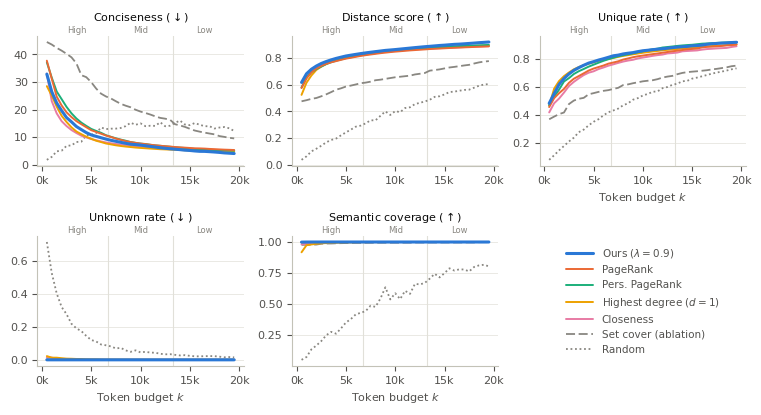

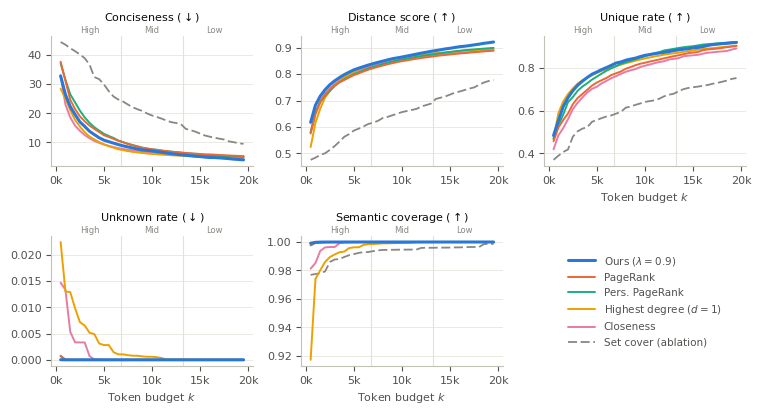

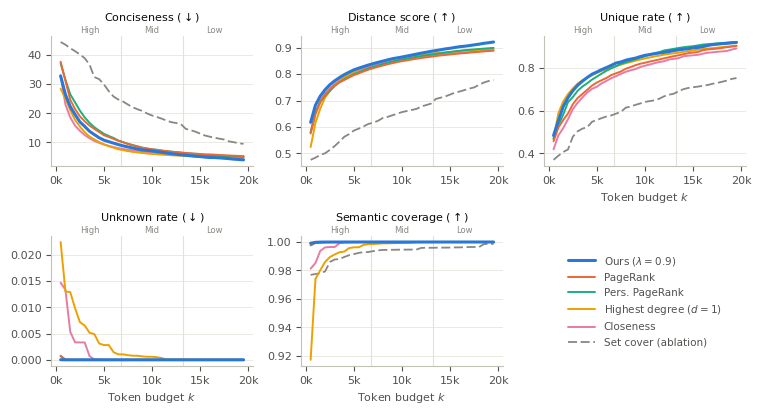

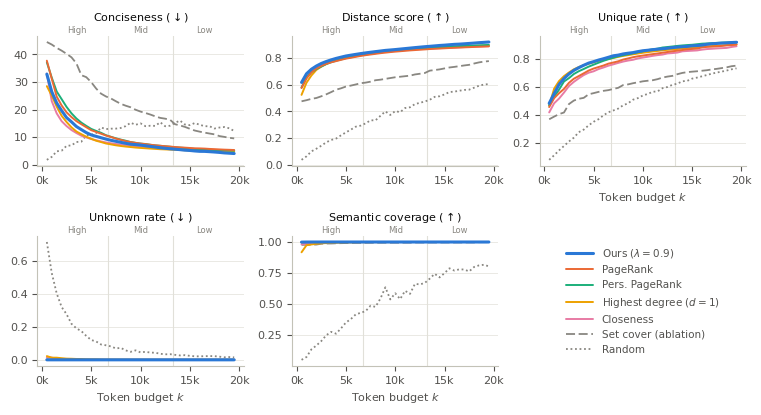

In [227]:
METHODS = ["highest_degree_dist_1", "closeness_centrality", "pagerank", "personalized_pagerank", "discrete_set_cover", "0.9"]
df_k = (perf_df_all
 .filter(pl.col("file_type").is_in(METHODS))
 .group_by(["family", "file_type", "k"])          # averages random's 20 draws
 .agg([pl.col(m).mean() for m in METRIC_CORE + ["uncovered_branche_rate"]])
 .sort(["family", "file_type", "k"])
 )

# main text: five core metrics
plot_metrics_vs_k(df_k, METRIC_CORE, fname="figures/metrics_vs_k.png")

df_k_all = (perf_df_all
 .filter(pl.col("file_type").is_in(METHODS + ["k_random_all_samples"]))
 .group_by(["family", "file_type", "k"])          # averages random's 20 draws
 .agg([pl.col(m).mean() for m in METRIC_CORE + ["uncovered_branche_rate"]])
 .sort(["family", "file_type", "k"])
 )

plot_metrics_vs_k(df_k, METRIC_CORE, fname="figures/metrics_vs_k.png")
plot_metrics_vs_k(df_k_all, METRIC_CORE, fname="figures/metrics_vs_k_all.png")



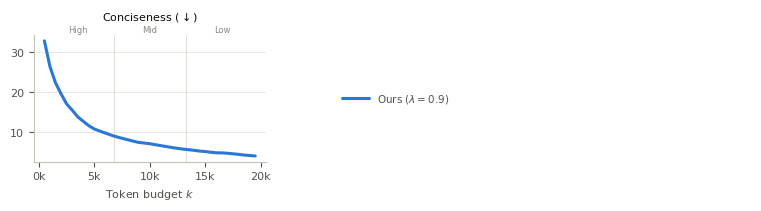

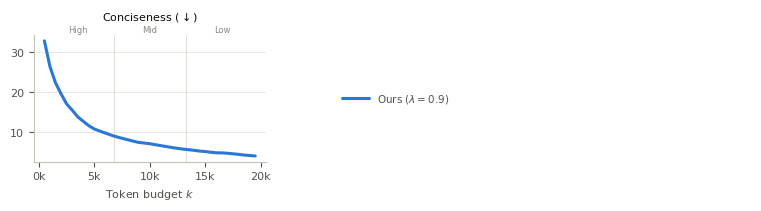

In [223]:


df_k_all_hi = (perf_df_all
 .filter(pl.col("file_type") == "0.9")
 .group_by(["family", "file_type", "k"])          # averages random's 20 draws
 .agg([pl.col(m).mean() for m in ["conciseness"]])
 .sort(["family", "file_type", "k"])
 )

df_k_all_hi
plot_metrics_vs_k(df_k_all_hi, ["conciseness"])


In [225]:
perf_df_all.filter(pl.col("file_type") == "0.9").filter(pl.col("conciseness") <= 11)

category,file_type,k,conciseness,distance_score,uniqueness_entropy,uncovered_branche_rate,unknown_rate,tree_complexity,unique_rate,semantic_coverage,family
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""greedy_tree_margin""","""0.9""",5000,10.788342,0.817023,0.972894,0.014691,0.0,5.754301,0.781777,0.999991,"""ours"""
"""greedy_tree_margin""","""0.9""",5500,10.270358,0.823301,0.974712,0.013499,0.0,5.623164,0.793153,0.999992,"""ours"""
"""greedy_tree_margin""","""0.9""",6000,9.767757,0.829312,0.975972,0.012589,0.0,5.482297,0.802557,0.999993,"""ours"""
"""greedy_tree_margin""","""0.9""",6500,9.273954,0.835152,0.977321,0.011831,0.0,5.34143,0.812849,0.999993,"""ours"""
"""greedy_tree_margin""","""0.9""",7000,8.83857,0.840413,0.978917,0.010834,0.0,5.232654,0.823749,0.999998,"""ours"""
…,…,…,…,…,…,…,…,…,…,…,…
"""greedy_tree_margin""","""0.9""",17500,4.591138,0.911567,0.989543,0.003835,0.0,3.64585,0.912091,0.999999,"""ours"""
"""greedy_tree_margin""","""0.9""",18000,4.450098,0.91425,0.989975,0.003792,0.0,3.577205,0.914475,0.999999,"""ours"""
"""greedy_tree_margin""","""0.9""",18500,4.273998,0.91734,0.990174,0.002947,0.0,3.504377,0.915991,1.0,"""ours"""


In [ ]:
df_k.filter(pl.col("semantic_coverage") >= 0.99).select(["family", "file_type", "k"]).group_by(["family", "file_type"]).agg(pl.col("k").min().alias("min_k"))
df_k.filter(pl.col("unknown_rate") == 0.).select(["family", "file_type", "k"]).group_by(["family", "file_type"]).agg(pl.col("k").min().alias("min_k"))
df_k.filter(pl.col("concisene") == 0.).select(["family", "file_type", "k"]).group_by(["family", "file_type"]).agg(pl.col("k").min().alias("min_k"))



family,file_type,min_k
str,str,i64
"""degree-based""","""highest_degree_dist_1""",14000
"""centrality-based""","""closeness_centrality""",5000
"""ours(ablation)""","""discrete_set_cover""",500
"""centrality-based""","""pagerank""",2000
"""centrality-based""","""personalized_pagerank""",1500
"""ours""","""0.9""",1000


In [207]:
df_k

family,file_type,k,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage,uncovered_branche_rate
str,str,i64,f64,f64,f64,f64,f64,f64
"""centrality-based""","""closeness_centrality""",500,33.038982,0.581732,0.41896,0.014713,0.981271,0.132893
"""centrality-based""","""closeness_centrality""",1000,23.006241,0.655334,0.484182,0.013348,0.985254,0.055233
"""centrality-based""","""closeness_centrality""",1500,18.602795,0.700542,0.51792,0.00533,0.993708,0.027627
"""centrality-based""","""closeness_centrality""",2000,15.769469,0.727313,0.560477,0.003337,0.996236,0.017248
"""centrality-based""","""closeness_centrality""",2500,13.997681,0.747362,0.607107,0.003315,0.996455,0.011809
…,…,…,…,…,…,…,…,…
"""ours(ablation)""","""discrete_set_cover""",17500,10.999047,0.750551,0.730423,0.0,0.996481,0.084377
"""ours(ablation)""","""discrete_set_cover""",18000,10.369729,0.760446,0.73584,0.0,0.996517,0.061777
"""ours(ablation)""","""discrete_set_cover""",18500,10.083727,0.768913,0.741278,0.0,0.998517,0.046782


In [179]:
perf_df_all["file_type"].unique().to_list()

['0.4',
 'pagerank',
 '0.6',
 'discrete_set_cover',
 '1.0',
 'most_children',
 'closeness_centrality',
 '0.2',
 '0.0',
 '0.9',
 'highest_degree_dist_1',
 '0.8',
 '0.7',
 '0.5',
 'highest_degree',
 'k_random_all_samples',
 'personalized_pagerank',
 '0.3',
 '0.1']

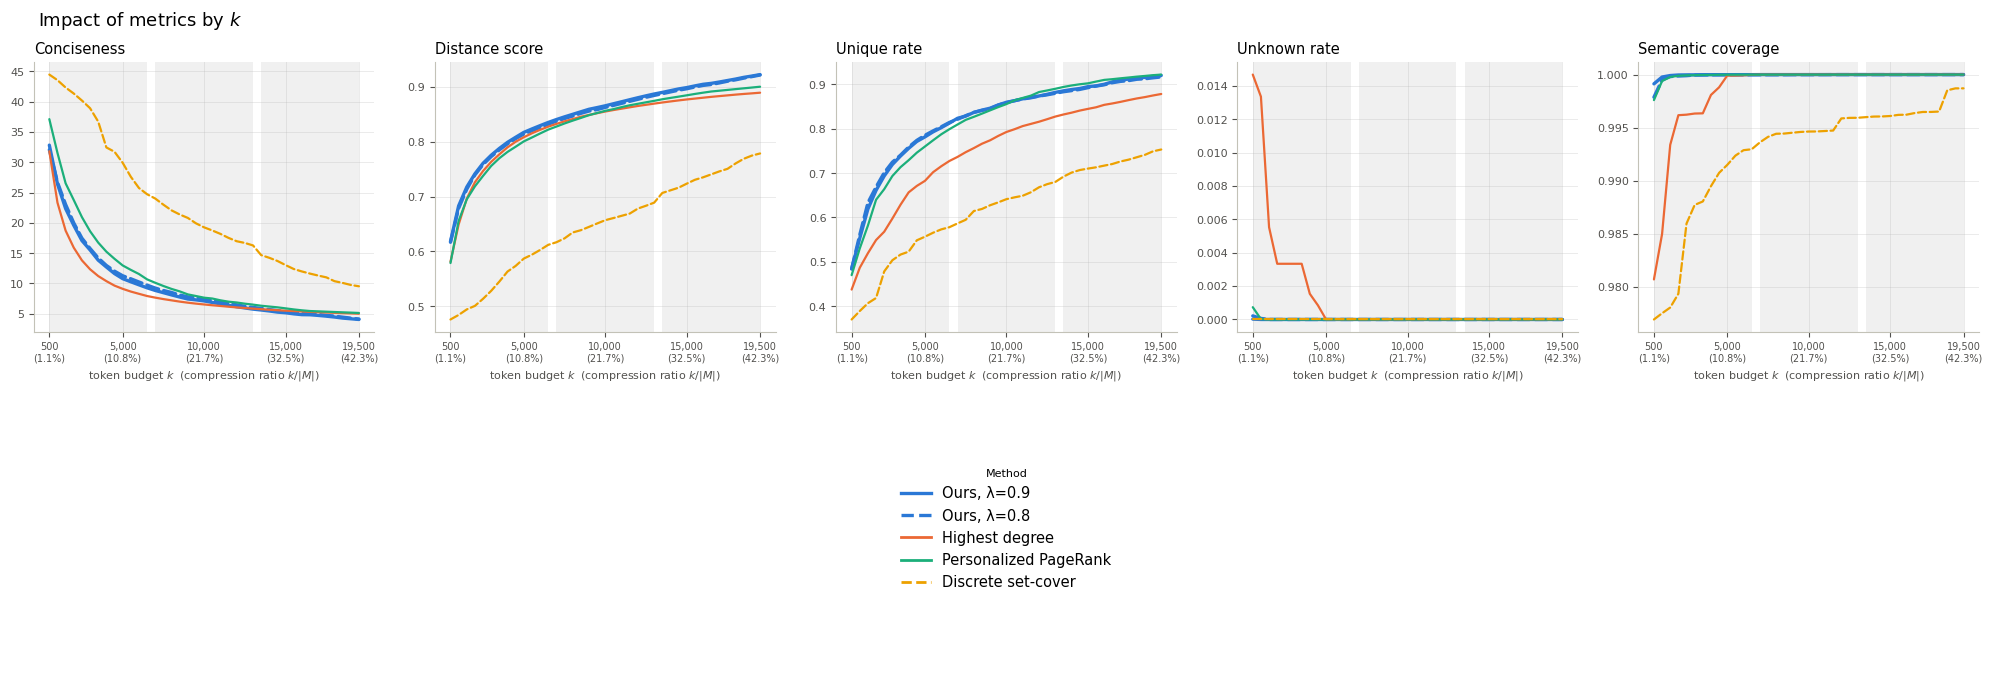

In [185]:
def plot_candidate_performance(perf_df_all, metric_cols, n_mapped_concepts, compression_level_dict,
                                save_path=None, dpi=300, title=None):
    """
    2x5 small-multiples grid of metric-vs-k curves, one line per series in `series_map`,
    aggregated over `iter` where present (k-random) and sorted by k. Slots left over after
    the metric panels merge into one wide legend box rather than a single cramped cell.
    Pass `save_path` to also write the figure to disk at `dpi` (default 300, print/
    publication quality).
    """
    _PALETTE = {
        "ours_0.9": "#2a78d6",
        "ours_0.8": "#2a78d6",
        "highest_degree": "#eb6834",
        "personalized_pagerank": "#1baf7a",
        "discrete_set_cover": "#eda100",
        # "k_random": "#8a8a86",
    }
    _LINESTYLE = {
        "ours_0.9": "-",
        "ours_0.8": "--",
        "highest_degree": "-",
        "personalized_pagerank": "-",
        "discrete_set_cover": "--",
        # "k_random": ":",
    }
    _LINEWIDTH = {"ours_0.9": 2.4, "ours_0.8": 2.4}  # everything else defaults to 1.6
    _DISPLAY_NAME = {
        "ours_0.9": "Ours, λ=0.9",
        "ours_0.8": "Ours, λ=0.8",
        "highest_degree": "Highest degree",
        "personalized_pagerank": "Personalized PageRank",
        "discrete_set_cover": "Discrete set-cover",
        # "k_random": "k-random",
    }
    # explicit (category, file_type) -> series key, so the plot shows exactly the six-way
    # comparison the paper makes -- not every baseline in perf_df_all (closeness_centrality,
    # pagerank, most_children, highest_degree_dist_1 stay out, and k_random's 20 iters collapse
    # into one series instead of 20 overlapping raw lines)
    
    series_map = {
        ("greedy_tree_margin", "0.9"): "ours_0.9",
        ("greedy_tree_margin", "0.8"): "ours_0.8",
        ("baseline", "highest_degree"): "highest_degree",
        ("baseline", "personalized_pagerank"): "personalized_pagerank",
        ("baseline", "discrete_set_cover"): "discrete_set_cover",
        # ("baseline", "k_random_all_samples"): "k_random",
    }
    n_row, n_col = 2, 5
    assert len(metric_cols) <= n_row * n_col - 1, "2x5 grid only fits 9 metric panels + a legend box"

    fig = plt.figure(figsize=(4.0 * n_col, 3.4 * n_row))
    gs = fig.add_gridspec(n_row, n_col)
    axes = [fig.add_subplot(gs[i // n_col, i % n_col]) for i in range(len(metric_cols))]

    # remaining slots merge into one wide legend box -- gs[r0:, c0:] spans everything
    # from the first unused slot to the end of the grid.
    r0, c0 = divmod(len(metric_cols), n_col)
    legend_ax = fig.add_subplot(gs[r0:, c0:])
    legend_ax.axis("off")

    # one row per series: aggregate over iter (mean) if present, sort by k
    group_cols = ["category", "file_type", "k"]
    agg_df = (
        perf_df_all.group_by(group_cols)
        .agg([pl.col(m).mean() for m in metric_cols])
        .sort("k")
    )

    # max k actually plotted, computed once over every series in series_map --
    # not left over from whichever series happens to be last in the dict, which
    # would silently truncate tick labels if that series had a shorter k range.
    plotted_mask = pl.struct(["category", "file_type"]).is_in(
        [{"category": c, "file_type": f} for c, f in series_map]
    )
    k_max = agg_df.filter(plotted_mask)["k"].max()

    for ax, metric in zip(axes, metric_cols):
        for (category, file_type), key in series_map.items():
            sub = agg_df.filter((pl.col("category") == category) & (pl.col("file_type") == file_type))
            if sub.is_empty():
                continue
            ax.plot(
                sub["k"], sub[metric],
                color=_PALETTE[key],
                linestyle=_LINESTYLE[key],
                linewidth=_LINEWIDTH.get(key, 1.6),
                solid_capstyle="round", dash_capstyle="round",
            )

        ax.set_title(metric.replace("_", " ").capitalize(), fontsize=10.5, loc="left")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25, linewidth=0.7)
        xticks = [500, 5000, 10000, 15000, 19500]
        xticks = [t for t in xticks if t <= k_max]
        ax.set_xticks(xticks)
        ax.set_xticklabels([f"{t:,}\n({t / n_mapped_concepts * 100:.1f}%)" for t in xticks], fontsize=7)
        ax.set_xlabel("token budget $k$  (compression ratio $k/|M|$)", fontsize=8)

        for lo, hi in compression_level_dict.values():
            ax.axvspan(lo, hi, color="black", alpha=0.06, linewidth=0, zorder=0)

    handles = [
        plt.Line2D([0], [0], color=_PALETTE[key], linestyle=_LINESTYLE[key],
                   linewidth=max(_LINEWIDTH.get(key, 1.6), 2.0), label=_DISPLAY_NAME[key])
        for key in series_map.values()
    ]
    # more than 6 series (e.g. the lambda sweep) needs two legend columns to stay readable
    legend_ncol = 1 if len(handles) <= 6 else 2
    legend_fontsize = 10.5 if len(handles) <= 6 else 9
    legend_ax.legend(handles=handles, loc="center", fontsize=legend_fontsize, ncol=legend_ncol,
                      title="Method", frameon=False)
    if title is None:
        title = "Impact of metrics by $k$"
    
    fig.suptitle(title, fontsize=13, x=0.02, ha="left")
    fig.tight_layout()



plot_candidate_performance(
    perf_df_all,
    metric_cols=METRIC_CORE,
    n_mapped_concepts=46_150,
    compression_level_dict=compression_level_dict,
)

# correlation

,distance_score,semantic_coverage,uniqueness_entropy,unique_rate,uncovered_branche_rate,unknown_rate,tree_complexity,conciseness
distance_score,1.0,1.0,1.0,1.0,-1.0,NaN,-1.0,-1.0
semantic_coverage,1.0,1.0,1.0,1.0,-1.0,NaN,-1.0,-1.0
uniqueness_entropy,1.0,1.0,1.0,1.0,-1.0,NaN,-1.0,-1.0
unique_rate,1.0,1.0,1.0,1.0,-1.0,NaN,-1.0,-1.0
uncovered_branche_rate,-1.0,-1.0,-1.0,-1.0,1.0,NaN,1.0,1.0
unknown_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tree_complexity,-1.0,-1.0,-1.0,-1.0,1.0,NaN,1.0,1.0
conciseness,-1.0,-1.0,-1.0,-1.0,1.0,NaN,1.0,1.0


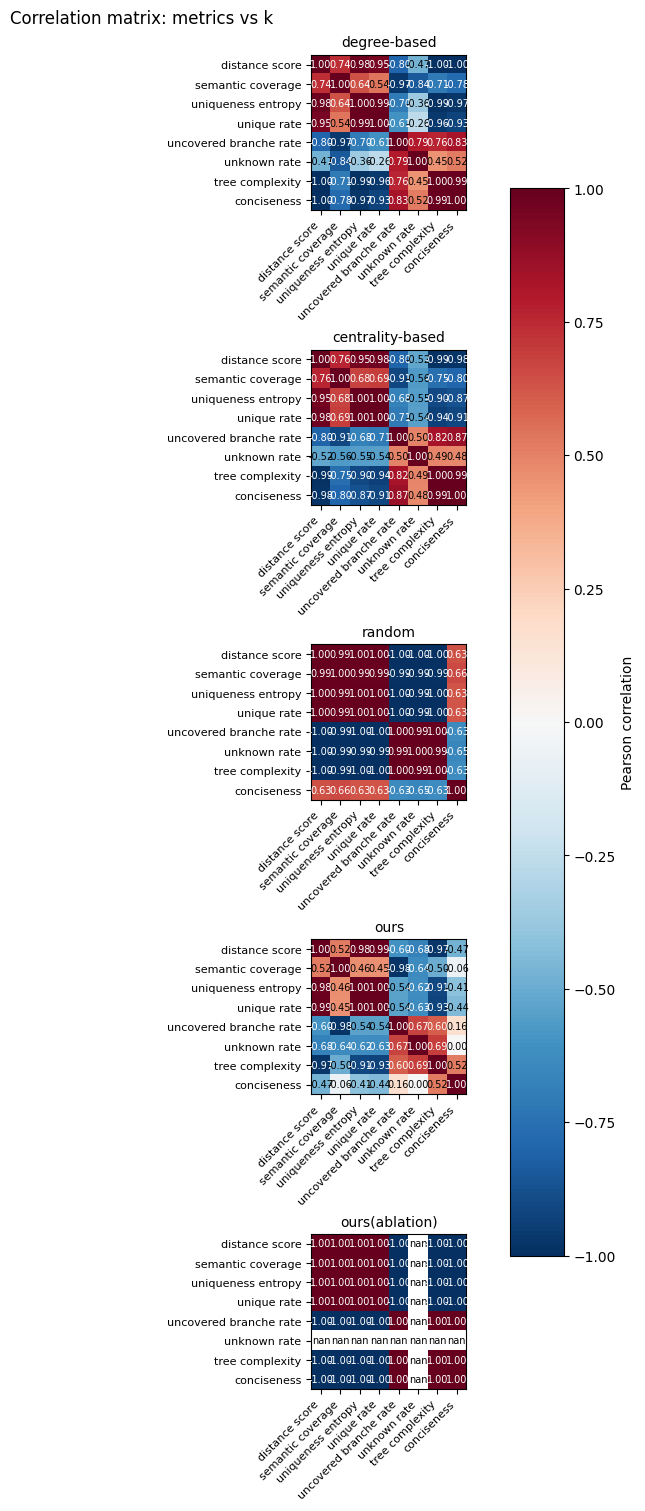

In [62]:
corr_cols = [
 'distance_score',
 'semantic_coverage',
 'uniqueness_entropy',
 'unique_rate',
 'uncovered_branche_rate',
 'unknown_rate',
 'tree_complexity',
 'conciseness',
 ]
family_list = ["degree-based", "centrality-based", "random", "ours", "ours(ablation)"]
fig, ax = plt.subplots(5, 1, figsize=(10, 15), constrained_layout=True)

for family in family_list:
    corr_df = perf_df_all.filter(pl.col("family") == family).select(corr_cols).to_pandas().corr(method="spearman")

    im = ax[family_list.index(family)].imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1)

    ax[family_list.index(family)].set_xticks(range(len(corr_cols)))
    ax[family_list.index(family)].set_yticks(range(len(corr_cols)))
    ax[family_list.index(family)].set_xticklabels([c.replace("_", " ") for c in corr_cols], rotation=45, ha="right", fontsize=8)
    ax[family_list.index(family)].set_yticklabels([c.replace("_", " ") for c in corr_cols], fontsize=8)
    ax[family_list.index(family)].set_title(family, fontsize=10)

    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            v = corr_df.values[i, j]
            ax[family_list.index(family)].text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.6 else "black", fontsize=7)

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
fig.suptitle("Correlation matrix: metrics vs k", fontsize=12)
# fig.tight_layout()

corr_df


ValueError: too many values to unpack (expected 2)

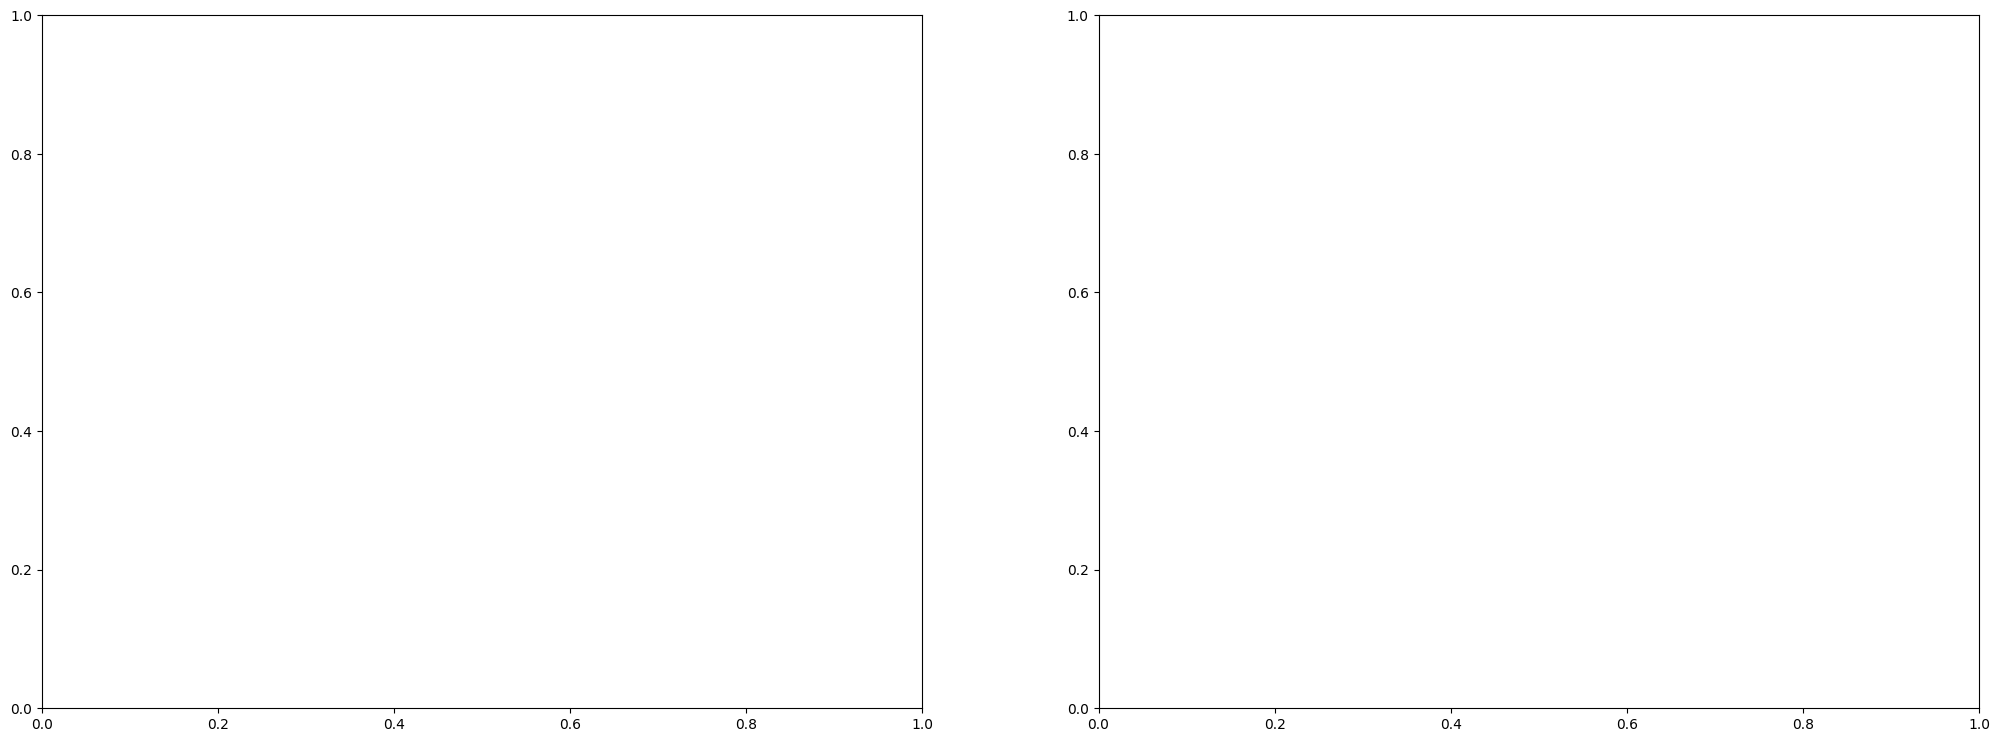

In [39]:
def plot_candidate_performance(n_row, n_col,perf_df_all, metric_cols):
    """
    2x5 grid of metric-vs-k curves, one line per (category, file_type) series -- last slot
    holds the shared legend. Hue-varied ordinal ramp (red -> yellow -> green) keyed on sorted
    series order; baseline = dotted, greedy_tree_margin = solid, a second encoding on top of
    color so the two arms are distinguishable even without reading the legend.
    """
    series_keys = perf_df_all.select(["category", "family", "file_type"]).unique().sort(["category", "family"]).rows()

    cmap = plt.get_cmap("RdYlGn")
    colors = {key: cmap(i / max(len(series_keys) - 1, 1)) for i, key in enumerate(series_keys)}
    linestyles = {key: (":" if key[0] == "baseline" else "-") for key in series_keys}

    fig, axes = plt.subplots(n_row, n_col, figsize=(25, 9))
    axes = axes.flatten()

    for ax, metric in zip(axes, metric_cols):
        for category, family in series_keys:
            sub = perf_df_all.filter((pl.col("category") == category) & (pl.col("family") == family))
            ax.plot(sub["k"], sub[metric], color=colors[(category, family)], linestyle=linestyles[(category, family)],
                     linewidth=2, marker="o", markersize=3)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("k")
        ax.grid(alpha=0.3)

    axes[-1].axis("off")  # 10th slot unused by metrics -- holds the shared legend instead
    handles = [
        plt.Line2D([0], [0], color=colors[key], linestyle=linestyles[key], lw=2, marker="o", markersize=4,
                   label=f"{key[0]} / {key[1]}")
        for key in series_keys
    ]
    axes[-1].legend(handles=handles, loc="center", fontsize=9, title="category / family", frameon=False)

    fig.suptitle("Candidate set performance vs k", fontsize=14)
    fig.tight_layout()

metric_cols = ["exact_rate"]
plot_candidate_performance(1,2,perf_df_all.filter(pl.col("family") == "centrality-based"), metric_cols)

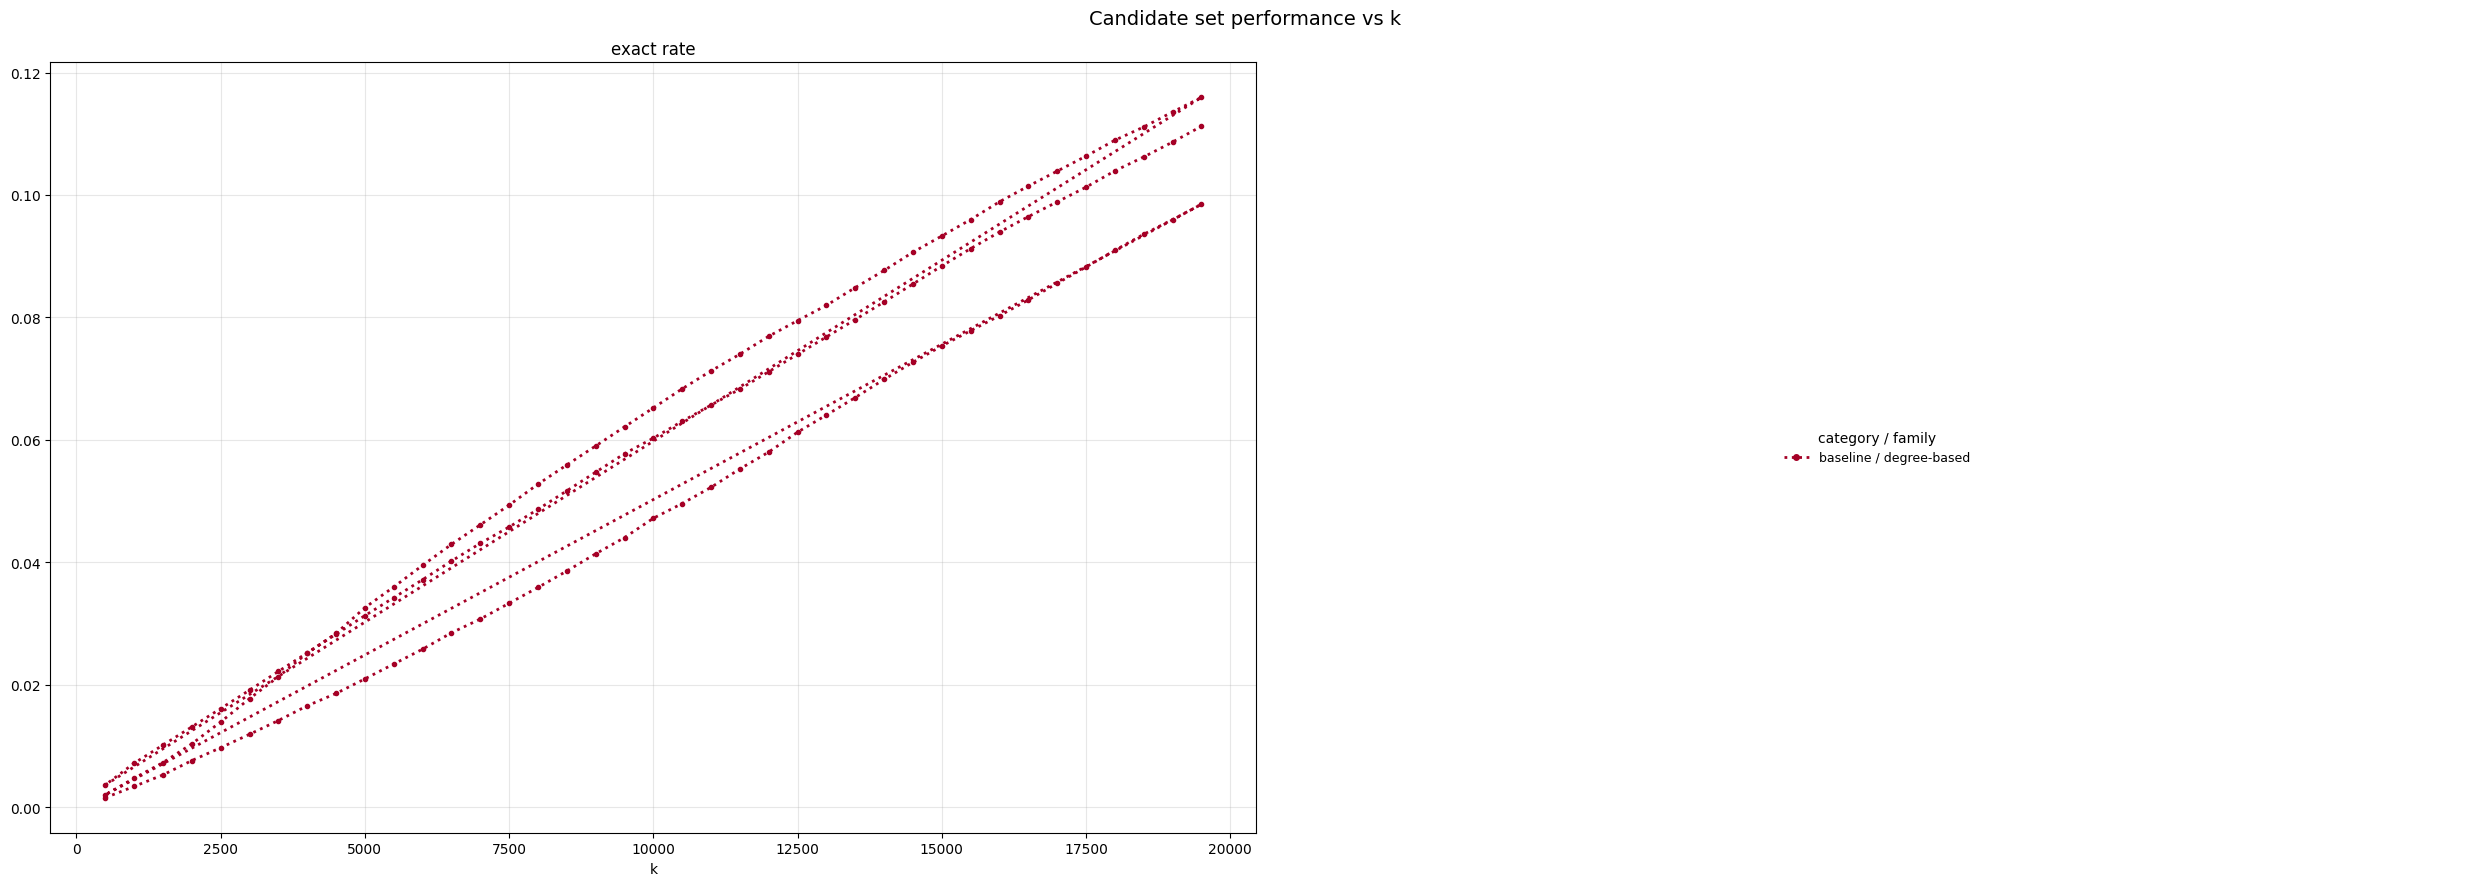

In [27]:
plot_candidate_performance(1,2,perf_df_all.filter(pl.col("family") == "degree-based"), metric_cols)

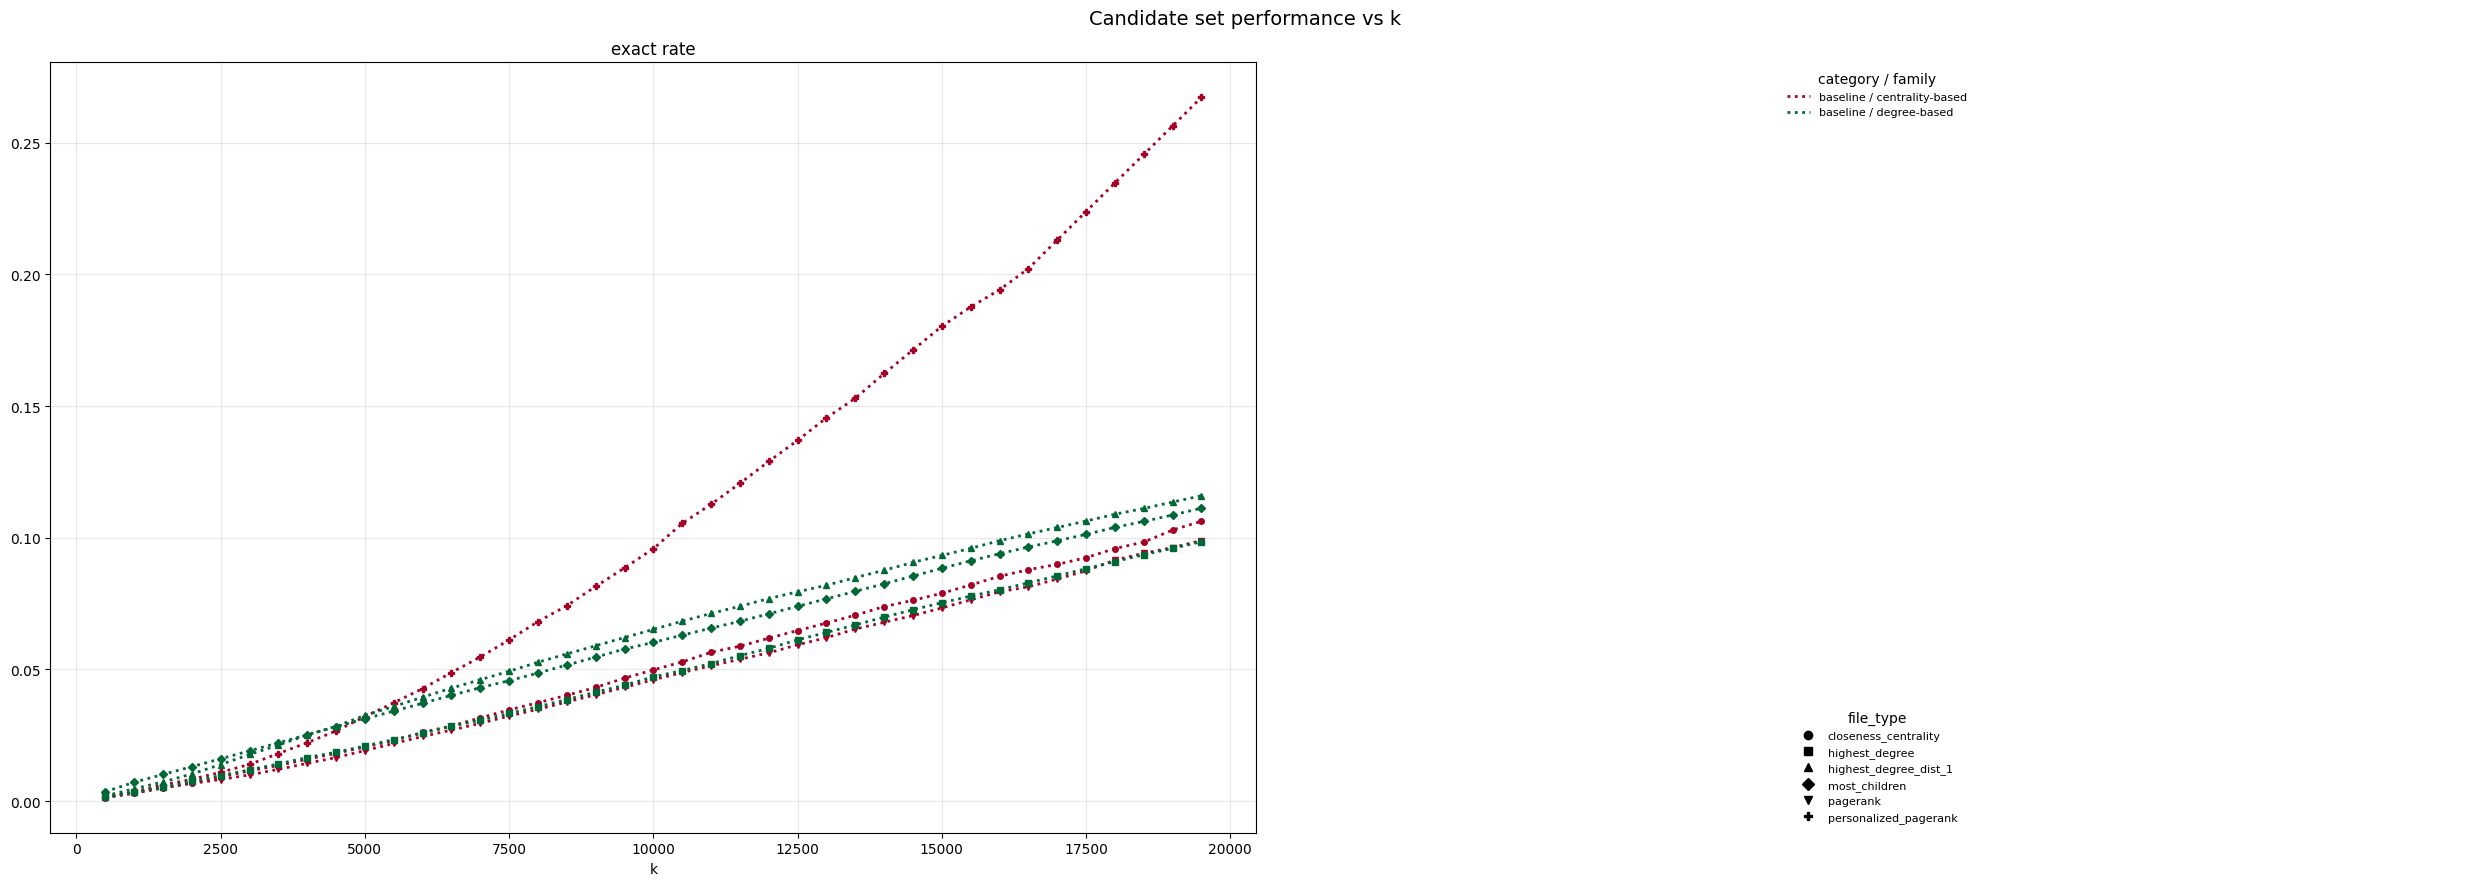

In [35]:
plot_candidate_performance(1,2,perf_df_all.filter(pl.col("family").is_in(["degree-based", "centrality-based"])), metric_cols)

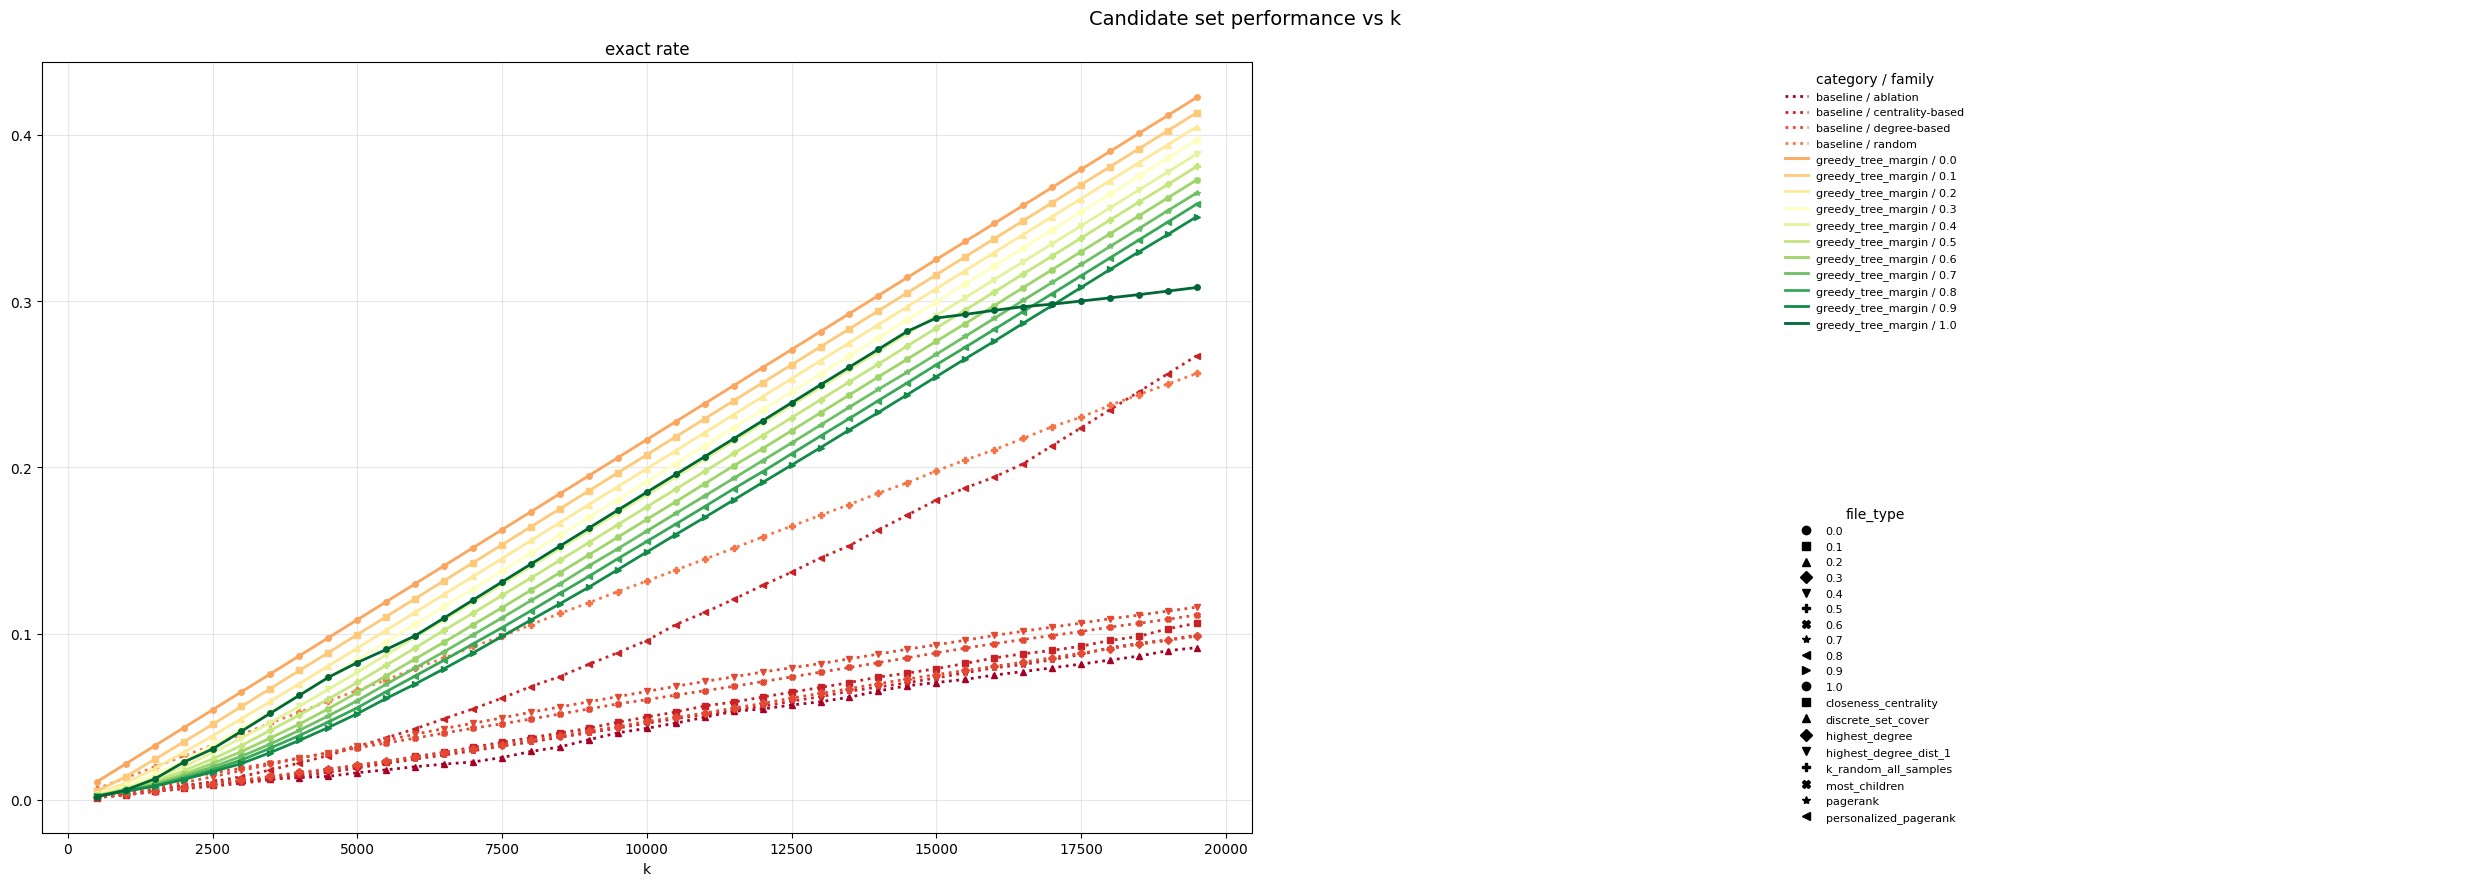

In [36]:
plot_candidate_performance(1,2,perf_df_all, metric_cols)
